# RAG Evaluation: Precision@K and Recall@K

Evaluates retrieval quality for every RAG-powered search in NourishAI by querying Pinecone directly (no running server required).

## Endpoints Evaluated

| # | Endpoint | Backend top_k |
|---|----------|--------------|
| 1 | `/api/recipes/search` | configurable (default 20) |
| 2 | `/api/chat` | 20 |
| 3 | `/api/planner/prompt` | 50 |
| 4 | `/api/planner/autofill` | 40 |
| 5 | `/api/recommendations/{user_id}` | 40 |

## Metrics
- **Precision@K** = `|relevant in top-K| / K`
- **Recall@K** = `|relevant in top-K| / |relevant in reference pool (top-300)|`

Relevance is judged by keyword/category matching against recipe name, category, cuisine, and ingredients.
The reference pool (top-300 results per query) approximates the total set of relevant items in the index.

In [16]:
import os
import re
import sys
import json
import time
import warnings
from typing import List, Callable, Tuple, Optional
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv
from openai import OpenAI
from pinecone import Pinecone

warnings.filterwarnings("ignore")
%matplotlib inline

# ── Load environment from project root .env ──────────────────────────────────
load_dotenv()
OPENAI_API_KEY      = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY      = os.getenv("GOOGLE_API_KEY")
PINECONE_API_KEY    = os.getenv("PINECONE_API_KEY")
PINECONE_INDEX_NAME = os.getenv("PINECONE_INDEX_NAME", "recipes")
EMBEDDING_MODEL     = "text-embedding-3-small"
LLM_JUDGE_MODEL     = "gemini-2.0-flash"
REFERENCE_POOL_K    = 100   # denominator for recall; judged by LLM
LLM_BATCH_SIZE      = 25    # recipes per LLM call

assert OPENAI_API_KEY,   "OPENAI_API_KEY not found — check .env"
assert GEMINI_API_KEY,   "GEMINI_API_KEY not found — check .env"
assert PINECONE_API_KEY, "PINECONE_API_KEY not found — check .env"

# OpenAI client for embeddings
oa_client = OpenAI(api_key=OPENAI_API_KEY)

# Gemini client via OpenAI-compatible endpoint
gemini_client = OpenAI(
    api_key=GEMINI_API_KEY,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
)

pc             = Pinecone(api_key=PINECONE_API_KEY)
pinecone_index = pc.Index(PINECONE_INDEX_NAME)

stats = pinecone_index.describe_index_stats()
print(f"Connected to '{PINECONE_INDEX_NAME}' — {stats.get('total_vector_count', '?')} vectors")

Connected to 'recipes' — 697 vectors


In [17]:
from datetime import datetime
from tenacity import (
    retry,
    stop_after_attempt,
    wait_exponential,
    retry_if_exception,
    before_sleep_log,
)
import logging
import openai

logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger(__name__)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")


def _is_rate_limit(exc: BaseException) -> bool:
    """
    Catch 429s from both the OpenAI SDK and the Gemini OpenAI-compatible
    endpoint. Gemini often surfaces rate-limits as APIStatusError(429) rather
    than the more specific RateLimitError subclass.
    """
    if isinstance(exc, openai.RateLimitError):
        return True
    if isinstance(exc, openai.APIStatusError) and exc.status_code == 429:
        return True
    return False


# Retry on any 429 — exponential backoff starting at 10 s (Gemini rate-limit
# windows reset slowly; starting at 2 s just hits the limit again immediately)
llm_retry = retry(
    retry=retry_if_exception(_is_rate_limit),
    wait=wait_exponential(multiplier=2, min=10, max=120),
    stop=stop_after_attempt(8),
    before_sleep=before_sleep_log(logger, logging.WARNING),
    reraise=True,
)


# ── Synthetic test-case generation ────────────────────────────────────────────
@llm_retry
def generate_test_cases(endpoint_label: str, n: int, style: str) -> List[dict]:
    """Generate n realistic, human-sounding test queries for an endpoint."""
    prompt = (
        f"Generate {n} realistic search queries a real person might type when using a recipe app.\n\n"
        f"Endpoint context: {endpoint_label}\n"
        f"Style guidance: {style}\n\n"
        "Hard rules — every query must feel genuinely human:\n"
        "1. Vary length: include short (2-4 words), medium (5-10 words), and 1-2 longer conversational phrases\n"
        "2. Zero food-blog language — never use: delicious, mouth-watering, perfect, amazing, easy, tasty, yummy\n"
        "3. Occasionally embed personal context: 'for my kids', 'after the gym', 'date night', 'Sunday meal prep', 'my partner hates cilantro'\n"
        "4. Occasionally embed natural constraints: 'no dairy', 'nothing too spicy', 'nut allergy in the house', 'under 30 minutes'\n"
        "5. Mix grammatical forms: keyword fragments, questions ('what can I make with...'), statements ('need something...'), commands ('show me...')\n"
        "6. Allow informal shorthand for 1-2 queries: 'quick chicken thing', 'BBQ stuff', 'veggie pasta'\n"
        "7. No two queries may start with the same word\n"
        "8. Each query must represent a clearly different person or situation\n"
        "9. Do NOT include the word 'recipe' in more than one query\n"
        "10. Do NOT produce generic filler like 'healthy and nutritious meals'\n\n"
        "Output ONLY a raw JSON array — no markdown fences, no explanation.\n"
        "Each item: {\"query\": \"...\", \"description\": \"3-6 word label\"}\n\n"
        "Example output:\n"
        "[{\"query\": \"something with leftover rotisserie chicken\", \"description\": \"Leftover chicken dishes\"},\n"
        " {\"query\": \"pasta carbonara\", \"description\": \"Italian pasta\"}]"
    )

    resp = gemini_client.chat.completions.create(
        model=LLM_JUDGE_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.9,
    )
    content = resp.choices[0].message.content.strip()
    content = re.sub(r"^```(?:json)?\s*", "", content)
    content = re.sub(r"\s*```$", "", content.strip())
    cases = json.loads(content)
    return [{"query": c["query"], "description": c["description"]} for c in cases[:n]]


print(f"Run ID : {RUN_ID}")
print("Retry decorator and test-case generator ready")

Run ID : 20260424_212113
Retry decorator and test-case generator ready


In [18]:
# ── Search helpers (mirrors api/index.py logic) ───────────────────────────────

def get_embedding(text: str) -> List[float]:
    resp = oa_client.embeddings.create(input=text, model=EMBEDDING_MODEL)
    return resp.data[0].embedding


def repair_recipe(rid: str, meta: dict) -> dict:
    """Reconstruct a recipe dict from Pinecone metadata."""
    nutri_str = meta.get("nutrition")
    try:
        nutrition = json.loads(nutri_str) if isinstance(nutri_str, str) else (nutri_str or {})
    except Exception:
        nutrition = {}

    ingr = meta.get("ingredients", "[]")
    try:
        ingredients = json.loads(ingr) if isinstance(ingr, str) else (ingr or [])
    except Exception:
        ingredients = []

    return {
        "id":           rid,
        "name":         meta.get("title", "Unknown"),
        "category":     meta.get("category", ""),
        "cuisine":      meta.get("area", ""),
        "tags":         meta.get("tags", ""),
        "ingredients":  ingredients,
        "instructions": meta.get("instructions", ""),
        "nutrition":    nutrition,
    }


def pinecone_search(query: str, top_k: int) -> List[dict]:
    """Embed query, query Pinecone, return repaired recipe list."""
    emb = get_embedding(query)
    res = pinecone_index.query(vector=emb, top_k=top_k, include_metadata=True)
    return [repair_recipe(m["id"], m["metadata"]) for m in res.get("matches", [])]


print("Helper functions ready")

Helper functions ready


In [19]:
# ── LLM-based relevance judging ───────────────────────────────────────────────

def _recipe_summary(r: dict, idx: int) -> str:
    ingr = ", ".join(
        (x.get("item", "") if isinstance(x, dict) else str(x))
        for x in r.get("ingredients", [])[:8]
    )
    return (
        f"{idx}. Name: \"{r.get('name', '')}\", "
        f"Category: {r.get('category', '')}, "
        f"Cuisine: {r.get('cuisine', '')}, "
        f"Ingredients: {ingr}"
    )


@llm_retry
def _llm_judge_batch(query: str, recipes: List[dict]) -> List[bool]:
    """Ask Gemini 2.0 Flash to judge one batch of recipes for relevance to query."""
    if not recipes:
        return []

    lines = [_recipe_summary(r, i + 1) for i, r in enumerate(recipes)]
    prompt = (
        f'User query: "{query}"\n\n'
        "Rate each recipe below as relevant (1) or not relevant (0) to the query's intent.\n"
        "Be inclusive: same cuisine, category, or a key ingredient counts as relevant.\n\n"
        + "\n".join(lines)
        + "\n\nRespond with ONLY a JSON array of 0s and 1s, one per recipe, in order. "
        "Example for 3 recipes: [1, 0, 1]"
    )

    resp = gemini_client.chat.completions.create(
        model=LLM_JUDGE_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
    )
    content = resp.choices[0].message.content.strip()
    m = re.search(r"\[[\d,\s]+\]", content)
    if m:
        scores = json.loads(m.group())
        return [bool(int(s)) for s in scores[:len(recipes)]]
    return [True] * len(recipes)  # conservative fallback


def build_relevance_map(query: str, recipes: List[dict]) -> dict:
    """
    Return {recipe_id: bool} for every unique recipe using batched Gemini calls.
    """
    unique = list({r["id"]: r for r in recipes}.values())
    relevance = {}
    for i in range(0, len(unique), LLM_BATCH_SIZE):
        batch = unique[i : i + LLM_BATCH_SIZE]
        scores = _llm_judge_batch(query, batch)
        for recipe, score in zip(batch, scores):
            relevance[recipe["id"]] = score
        time.sleep(0.1)
    return relevance


print("LLM relevance judging functions ready (Gemini 2.0 Flash)")

LLM relevance judging functions ready (Gemini 2.0 Flash)


In [20]:
# ── Metrics, evaluation runner, and plot helper ───────────────────────────────

K_VALUES = [1, 3, 5, 10, 20]


def precision_at_k(results: List[dict], relevance_map: dict, k: int) -> float:
    """Fraction of top-K results judged relevant by the LLM."""
    top = results[:k]
    if not top:
        return 0.0
    return sum(1 for r in top if relevance_map.get(r["id"], False)) / k


def recall_at_k(
    results:        List[dict],
    reference_pool: List[dict],
    relevance_map:  dict,
    k:              int,
) -> float:
    """
    Fraction of LLM-relevant recipes in the reference pool that appear in top-K.
    """
    total = sum(1 for r in reference_pool if relevance_map.get(r["id"], False))
    if total == 0:
        return 0.0
    top_ids = {r["id"] for r in results[:k]}
    hit = sum(
        1 for r in reference_pool
        if relevance_map.get(r["id"], False) and r["id"] in top_ids
    )
    return hit / total


def evaluate_query(
    query:        str,
    search_top_k: int,
    k_values:     List[int],
) -> dict:
    """Run one query; build LLM relevance map; return precision@k and recall@k."""
    results  = pinecone_search(query, top_k=max(search_top_k, max(k_values)))
    ref_pool = pinecone_search(query, top_k=max(REFERENCE_POOL_K, max(k_values)))

    relevance_map = build_relevance_map(query, results + ref_pool)

    row = {"query": query}
    for k in k_values:
        row[f"precision@{k}"] = round(precision_at_k(results, relevance_map, k), 4)
        row[f"recall@{k}"]    = round(recall_at_k(results, ref_pool, relevance_map, k), 4)
    row["n_retrieved"]     = len(results)
    row["n_relevant_pool"] = sum(1 for r in ref_pool if relevance_map.get(r["id"], False))
    return row


def run_experiment(
    test_cases:   List[dict],
    search_top_k: int,
    label:        str = "",
    k_values:     List[int] = K_VALUES,
) -> pd.DataFrame:
    """Run all test cases and return a results DataFrame."""
    rows = []
    for tc in test_cases:
        print(f"  [{label}] '{tc['query']}' ... ", end="", flush=True)
        row = evaluate_query(tc["query"], search_top_k, k_values)
        row["description"] = tc.get("description", "")
        row["endpoint"]    = label
        rows.append(row)
        print(f"P@5={row['precision@5']:.2f}  R@5={row['recall@5']:.2f}")
        time.sleep(0.3)
    return pd.DataFrame(rows)


def plot_pr(df: pd.DataFrame, title: str, k_values: List[int] = K_VALUES):
    """Per-query Precision@K and Recall@K curves with mean overlay."""
    p_cols = [f"precision@{k}" for k in k_values]
    r_cols = [f"recall@{k}"    for k in k_values]
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i, (_, row) in enumerate(df.iterrows()):
        c = colors[i % len(colors)]
        label = row["description"] if row["description"] else row["query"][:40]
        axes[0].plot(k_values, [row[c_] for c_ in p_cols], marker="o", label=label, color=c, alpha=0.7, linewidth=1.5)
        axes[1].plot(k_values, [row[c_] for c_ in r_cols], marker="o", label=label, color=c, alpha=0.7, linewidth=1.5)

    mean_p = df[p_cols].mean().values
    mean_r = df[r_cols].mean().values
    axes[0].plot(k_values, mean_p, color="black", linewidth=2.5, linestyle="--", label="Mean", zorder=5)
    axes[1].plot(k_values, mean_r, color="black", linewidth=2.5, linestyle="--", label="Mean", zorder=5)

    for ax, metric in zip(axes, ["Precision@K", "Recall@K"]):
        ax.set_title(f"{metric} — {title}")
        ax.set_xlabel("K")
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(mticker.FixedLocator(k_values))
        ax.legend(fontsize=7, loc="lower right")

    axes[0].set_ylabel("Precision")
    axes[1].set_ylabel("Recall")
    plt.tight_layout()
    plt.show()


print("Metrics and runner ready")

Metrics and runner ready


In [ ]:
# ── Generate synthetic test cases for all 5 endpoints ─────────────────────────
print("Generating synthetic test cases with Gemini 2.0 Flash...\n")
num = 12
SEARCH_CASES = generate_test_cases(
    endpoint_label="/api/recipes/search — typed search bar",
    n=num,
    style=(
        "Short-to-medium queries as typed into a search box. "
        "Mix ingredient-based ('chicken thighs spinach'), dish-based ('shakshuka'), "
        "and cuisine-based ('something Thai'). Some are single words or fragments."
    ),
)
print(f"  /api/recipes/search   — {len(SEARCH_CASES)} cases")

CHAT_CASES = generate_test_cases(
    endpoint_label="/api/chat — conversational recipe assistant",
    n=num,
    style=(
        "Natural language requests as if texting a knowledgeable friend. "
        "Include situational context (occasion, mood, time pressure), "
        "dietary needs, or fridge contents. Full sentences or near-sentences."
    ),
)
print(f"  /api/chat             — {len(CHAT_CASES)} cases")

PLANNER_CASES = generate_test_cases(
    endpoint_label="/api/planner/prompt — AI weekly meal planner",
    n=num,
    style=(
        "Multi-day planning requests. "
        "Vary between themed weeks ('all Japanese this week'), dietary goals "
        "('trying to cut carbs'), family constraints, and budget/time considerations."
    ),
)
print(f"  /api/planner/prompt   — {len(PLANNER_CASES)} cases")

AUTOFILL_CASES = generate_test_cases(
    endpoint_label="/api/planner/autofill — preference-based plan autofill",
    n=num,
    style=(
        "Compact preference descriptions that capture a user's taste profile — "
        "favourite cuisines, dietary style, or ingredient preferences. "
        "Think of it as describing your palate in a sentence or less."
    ),
)
print(f"  /api/planner/autofill — {len(AUTOFILL_CASES)} cases")

RECO_CASES = generate_test_cases(
    endpoint_label="/api/recommendations — personalised recipe recommendations",
    n=num,
    style=(
        "Personal taste expressions used to surface tailored recommendations. "
        "Each should reveal something specific about what the person enjoys — "
        "cuisines, textures, occasions, or cooking habits."
    ),
)
print(f"  /api/recommendations  — {len(RECO_CASES)} cases")

total = sum(len(c) for c in [SEARCH_CASES, CHAT_CASES, PLANNER_CASES, AUTOFILL_CASES, RECO_CASES])
print(f"\nTotal test cases: {total}")

print("\nSample queries per endpoint:")
for label, cases in [
    ("search",  SEARCH_CASES),
    ("chat",    CHAT_CASES),
    ("planner", PLANNER_CASES),
    ("autofill",AUTOFILL_CASES),
    ("reco",    RECO_CASES),
]:
    print(f"  [{label:8s}] {cases[0]['query']}")

Generating synthetic test cases with Gemini 2.0 Flash...

  /api/recipes/search   — 6 cases
  /api/chat             — 6 cases
  /api/planner/prompt   — 6 cases
  /api/planner/autofill — 6 cases
  /api/recommendations  — 6 cases

Total test cases: 30

Sample queries per endpoint:
  [search  ] quick chicken thing
  [chat    ] What can I make with sweet potatoes and ground beef? Something not too heavy.
  [planner ] vegetarian meals under $10 total
  [autofill] quick chicken thing
  [reco    ] show me Thai curries, but not too hot


---
## 1. `/api/recipes/search`
Manual recipe search bar. Uses `top_k=20` (configurable via `req.limit`, defaulting to 20).  
Embeds the raw user query and retrieves the closest recipes.

Running /api/recipes/search experiment (top_k=20)...
  [/api/recipes/search] 'quick chicken thing' ... 

P@5=1.00  R@5=0.05
  [/api/recipes/search] 'show me a good shakshuka' ... P@5=1.00  R@5=0.19
  [/api/recipes/search] 'vegetarian dinner for my kids' ... P@5=0.80  R@5=0.06
  [/api/recipes/search] 'nothing too spicy, using ground beef' ... P@5=0.00  R@5=0.00
  [/api/recipes/search] 'what can I make with sweet potatoes and chickpeas' ... P@5=0.20  R@5=0.08
  [/api/recipes/search] 'need something Thai, my partner hates cilantro' ... P@5=1.00  R@5=0.18

Results:


,n_relevant_pool,precision@1,precision@3,precision@5,precision@10,precision@20,recall@1,recall@3,recall@5,recall@10,recall@20
description,,,,,,,,,,,
Fast chicken ideas,98,1.0,1.0000,1.0,1.0,1.00,0.0102,0.0306,0.0510,0.1020,0.2041
Authentic shakshuka guidance,27,1.0,1.0000,1.0,0.6,0.35,0.0370,0.1111,0.1852,0.2222,0.2593
Family veggie meals,72,1.0,0.6667,0.8,0.8,0.90,0.0139,0.0278,0.0556,0.1111,0.2500
Mild ground beef dishes,23,0.0,0.0000,0.0,0.0,0.05,0.0000,0.0000,0.0000,0.0000,0.0435
Sweet potato and chickpea,12,0.0,0.3333,0.2,0.3,0.20,0.0000,0.0833,0.0833,0.2500,0.3333
"Thai food, no cilantro",28,1.0,1.0000,1.0,0.7,0.60,0.0357,0.1071,0.1786,0.2500,0.4286



Mean Precision@5 = 0.667
Mean Recall@5    = 0.092


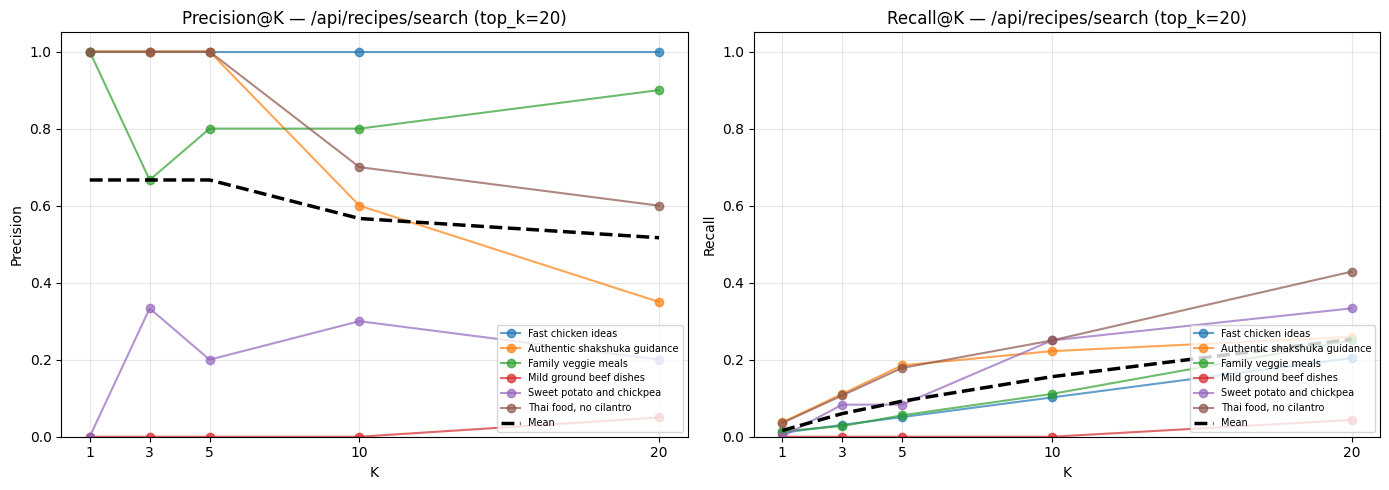

Saved → outputs/20260424_212113_search_results.csv


In [22]:
print("Running /api/recipes/search experiment (top_k=20)...")
df_search = run_experiment(SEARCH_CASES, search_top_k=20, label="/api/recipes/search")

display_cols = ["description", "n_relevant_pool"] + \
               [f"precision@{k}" for k in K_VALUES] + \
               [f"recall@{k}"    for k in K_VALUES]
print("\nResults:")
display(df_search[display_cols].set_index("description"))

print(f"\nMean Precision@5 = {df_search['precision@5'].mean():.3f}")
print(f"Mean Recall@5    = {df_search['recall@5'].mean():.3f}")

plot_pr(df_search, "/api/recipes/search (top_k=20)")

os.makedirs("outputs", exist_ok=True)
path = f"outputs/{RUN_ID}_search_results.csv"
df_search.to_csv(path, index=False)
print(f"Saved → {path}")

---
## 2. `/api/chat`
Chat-based recipe discovery. Embeds the user's natural-language message and retrieves `top_k=20`.  
Queries are more conversational than the search bar.

Running /api/chat experiment (top_k=20)...
  [/api/chat] 'What can I make with sweet potatoes and ground beef? Something not too heavy.' ... P@5=0.00  R@5=0.00
  [/api/chat] 'I need a quick dinner idea, under 20 minutes, using canned tomatoes.' ... P@5=1.00  R@5=0.09
  [/api/chat] 'Show me some vegetarian chili options for a potluck. Nut allergy in the house!' ... P@5=0.80  R@5=0.24
  [/api/chat] 'Sunday meal prep for the week: chicken and rice bowls. Low sodium, please.' ... P@5=0.60  R@5=0.05
  [/api/chat] 'My partner hates mushrooms. Salmon dishes that are quick to prepare?' ... P@5=0.80  R@5=0.15
  [/api/chat] 'BBQ ideas for a crowd. No ribs or pulled pork this time.' ... P@5=1.00  R@5=0.06

Results:


,n_relevant_pool,precision@1,precision@3,precision@5,precision@10,precision@20,recall@1,recall@3,recall@5,recall@10,recall@20
description,,,,,,,,,,,
Ground beef sweet potato dish,27,0.0,0.0000,0.0,0.3,0.25,0.0000,0.0000,0.0000,0.1111,0.1852
Quick tomato-based dinner,56,1.0,1.0000,1.0,1.0,0.90,0.0179,0.0536,0.0893,0.1786,0.3214
Nut-free vegetarian chili,17,1.0,0.6667,0.8,0.7,0.55,0.0588,0.1176,0.2353,0.4118,0.6471
Low sodium chicken rice,62,1.0,0.6667,0.6,0.6,0.70,0.0161,0.0323,0.0484,0.0968,0.2258
Salmon recipe without mushrooms,27,1.0,1.0000,0.8,0.8,0.65,0.0370,0.1111,0.1481,0.2963,0.4815
BBQ for a group,77,1.0,1.0000,1.0,1.0,0.80,0.0130,0.0390,0.0649,0.1299,0.2078



Mean Precision@5 = 0.700
Mean Recall@5    = 0.098


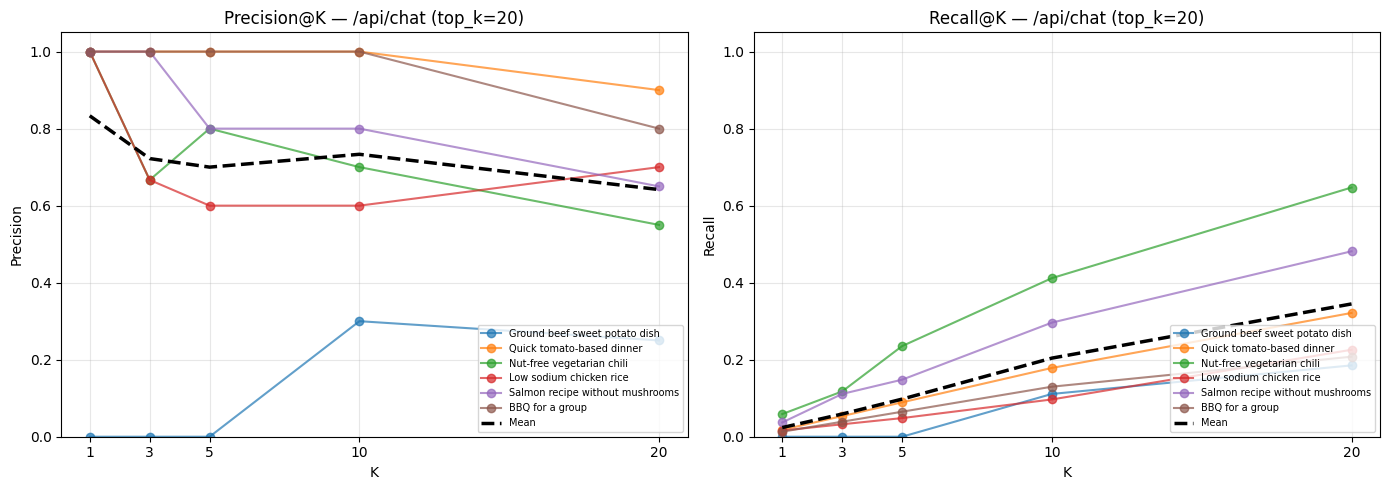

Saved → outputs/20260424_212113_chat_results.csv


In [23]:
print("Running /api/chat experiment (top_k=20)...")
df_chat = run_experiment(CHAT_CASES, search_top_k=20, label="/api/chat")

display_cols = ["description", "n_relevant_pool"] + \
               [f"precision@{k}" for k in K_VALUES] + \
               [f"recall@{k}"    for k in K_VALUES]
print("\nResults:")
display(df_chat[display_cols].set_index("description"))

print(f"\nMean Precision@5 = {df_chat['precision@5'].mean():.3f}")
print(f"Mean Recall@5    = {df_chat['recall@5'].mean():.3f}")

plot_pr(df_chat, "/api/chat (top_k=20)")

os.makedirs("outputs", exist_ok=True)
path = f"outputs/{RUN_ID}_chat_results.csv"
df_chat.to_csv(path, index=False)
print(f"Saved → {path}")

---
## 3. `/api/planner/prompt`
AI-driven planner arrangement. Embeds the user's planning prompt and retrieves `top_k=50` to give the LLM a larger candidate set for a full weekly plan.

Running /api/planner/prompt experiment (top_k=50)...
  [/api/planner/prompt] 'vegetarian meals under $10 total' ... P@5=0.80  R@5=0.05
  [/api/planner/prompt] 'I need something I can prep on Sunday for the week' ... P@5=0.80  R@5=0.04
  [/api/planner/prompt] 'quick chicken thing for after the gym' ... P@5=1.00  R@5=0.05
  [/api/planner/prompt] 'what can I make with ground turkey and zucchini' ... P@5=0.20  R@5=0.08
  [/api/planner/prompt] 'my partner hates cilantro - Asian-inspired food' ... P@5=0.80  R@5=0.08
  [/api/planner/prompt] 'show me a week of low-sodium meals' ... 

P@5=0.20  R@5=0.04

Results:


,n_relevant_pool,precision@1,precision@3,precision@5,precision@10,precision@20,recall@1,recall@3,recall@5,recall@10,recall@20
description,,,,,,,,,,,
Budget vegetarian options,73,1.0,1.0000,0.8,0.9,0.95,0.0137,0.0411,0.0548,0.1233,0.2603
Sunday meal prep ideas,91,1.0,1.0000,0.8,0.8,0.80,0.0110,0.0330,0.0440,0.0879,0.1758
Post-workout chicken,100,1.0,1.0000,1.0,1.0,1.00,0.0100,0.0300,0.0500,0.1000,0.2000
Ground turkey and zucchini,13,1.0,0.3333,0.2,0.2,0.20,0.0769,0.0769,0.0769,0.1538,0.3077
"Asian, no cilantro",50,0.0,0.6667,0.8,0.9,0.95,0.0000,0.0400,0.0800,0.1800,0.3800
Low sodium meal plan,28,1.0,0.3333,0.2,0.1,0.20,0.0357,0.0357,0.0357,0.0357,0.1429



Mean Precision@5  = 0.633
Mean Precision@10 = 0.650
Mean Recall@5     = 0.057
Mean Recall@20    = 0.244


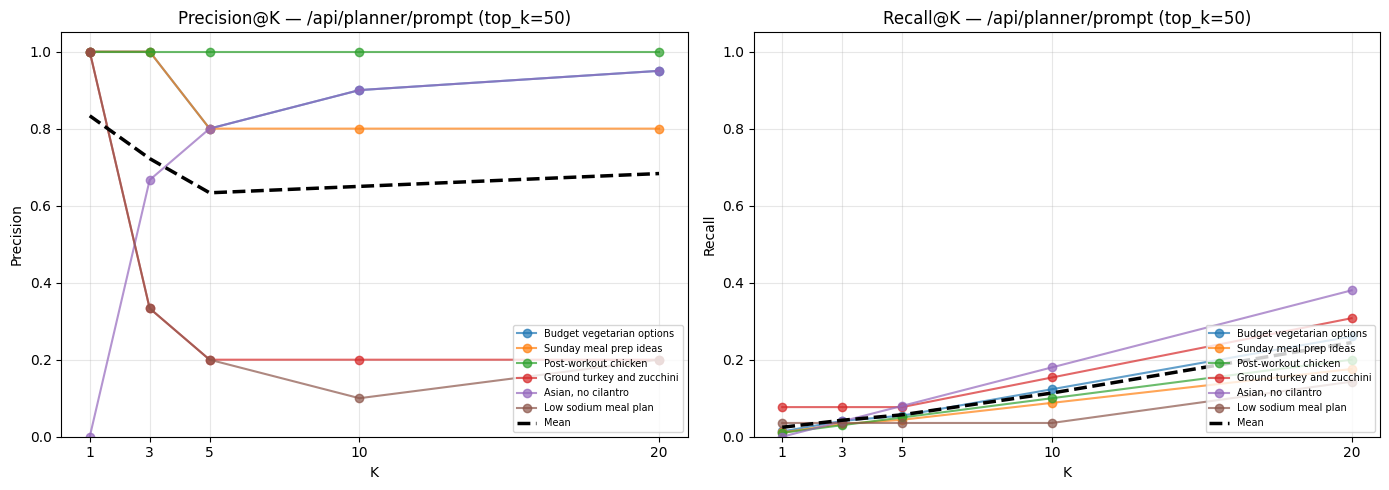

Saved → outputs/20260424_212113_planner_results.csv


In [24]:
print("Running /api/planner/prompt experiment (top_k=50)...")
df_planner = run_experiment(PLANNER_CASES, search_top_k=50, label="/api/planner/prompt")

display_cols = ["description", "n_relevant_pool"] + \
               [f"precision@{k}" for k in K_VALUES] + \
               [f"recall@{k}"    for k in K_VALUES]
print("\nResults:")
display(df_planner[display_cols].set_index("description"))

print(f"\nMean Precision@5  = {df_planner['precision@5'].mean():.3f}")
print(f"Mean Precision@10 = {df_planner['precision@10'].mean():.3f}")
print(f"Mean Recall@5     = {df_planner['recall@5'].mean():.3f}")
print(f"Mean Recall@20    = {df_planner['recall@20'].mean():.3f}")

plot_pr(df_planner, "/api/planner/prompt (top_k=50)")

os.makedirs("outputs", exist_ok=True)
path = f"outputs/{RUN_ID}_planner_results.csv"
df_planner.to_csv(path, index=False)
print(f"Saved → {path}")

---
## 4. `/api/planner/autofill`
One-click weekly schedule autofill. Derives the query string from the user's saved favorite categories and cuisines (e.g. `"Chicken Beef Italian cuisine"`), then retrieves `top_k=40`.  
Test cases simulate different user preference profiles.

Running /api/planner/autofill experiment (top_k=40)...
  [/api/planner/autofill] 'quick chicken thing' ... P@5=1.00  R@5=0.05
  [/api/planner/autofill] 'show me vegetarian meals under 500 calories' ... P@5=1.00  R@5=0.06
  [/api/planner/autofill] 'what can I make with zucchini and tomatoes?' ... P@5=0.80  R@5=0.07
  [/api/planner/autofill] 'need something for Sunday meal prep, high protein' ... P@5=0.20  R@5=0.01
  [/api/planner/autofill] 'date night dinner ideas, nothing too complicated' ... P@5=0.80  R@5=0.04
  [/api/planner/autofill] 'my partner hates cilantro, show me some Thai' ... P@5=1.00  R@5=0.15

Results:


,n_relevant_pool,precision@1,precision@3,precision@5,precision@10,precision@20,recall@1,recall@3,recall@5,recall@10,recall@20
description,,,,,,,,,,,
Fast chicken dinners,98,1.0,1.0000,1.0,1.0,1.00,0.0102,0.0306,0.0510,0.1020,0.2041
Low-calorie vegetarian,79,1.0,1.0000,1.0,0.9,0.90,0.0127,0.0380,0.0633,0.1139,0.2278
Zucchini tomato ideas,57,1.0,0.6667,0.8,0.8,0.85,0.0175,0.0351,0.0702,0.1404,0.2982
High protein meal prep,70,1.0,0.3333,0.2,0.3,0.40,0.0143,0.0143,0.0143,0.0429,0.1143
Simple date night,91,1.0,0.6667,0.8,0.9,0.95,0.0110,0.0220,0.0440,0.0989,0.2088
"Thai, no cilantro",34,1.0,1.0000,1.0,1.0,0.95,0.0294,0.0882,0.1471,0.2941,0.5588



Mean Precision@5  = 0.800
Mean Precision@10 = 0.817
Mean Recall@10    = 0.132
Mean Recall@20    = 0.269


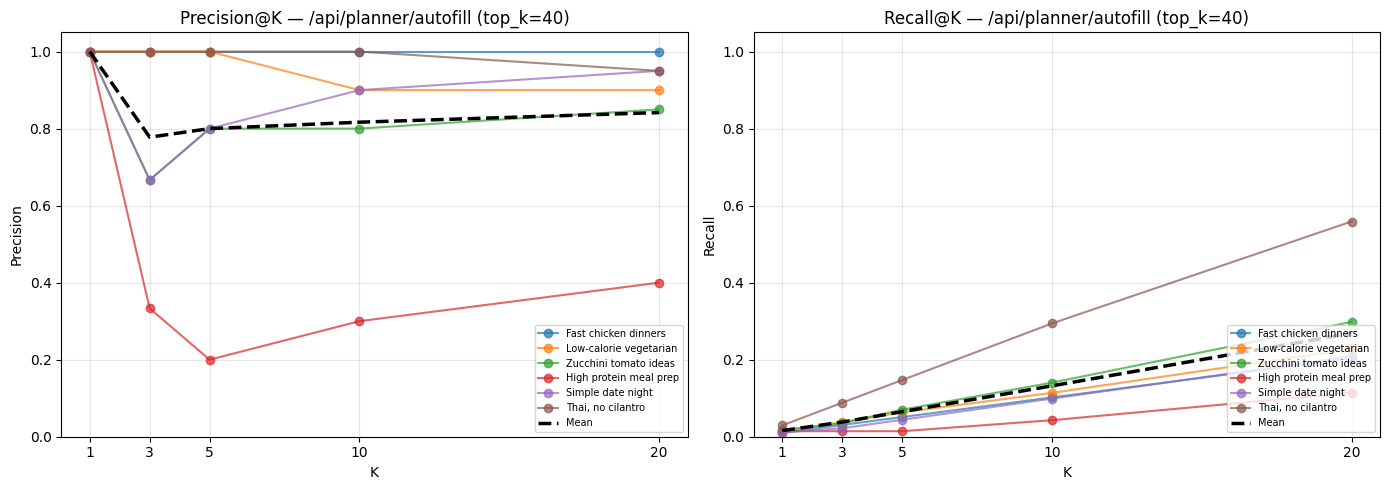

Saved → outputs/20260424_212113_autofill_results.csv


In [25]:
print("Running /api/planner/autofill experiment (top_k=40)...")
df_autofill = run_experiment(AUTOFILL_CASES, search_top_k=40, label="/api/planner/autofill")

display_cols = ["description", "n_relevant_pool"] + \
               [f"precision@{k}" for k in K_VALUES] + \
               [f"recall@{k}"    for k in K_VALUES]
print("\nResults:")
display(df_autofill[display_cols].set_index("description"))

print(f"\nMean Precision@5  = {df_autofill['precision@5'].mean():.3f}")
print(f"Mean Precision@10 = {df_autofill['precision@10'].mean():.3f}")
print(f"Mean Recall@10    = {df_autofill['recall@10'].mean():.3f}")
print(f"Mean Recall@20    = {df_autofill['recall@20'].mean():.3f}")

plot_pr(df_autofill, "/api/planner/autofill (top_k=40)")

os.makedirs("outputs", exist_ok=True)
path = f"outputs/{RUN_ID}_autofill_results.csv"
df_autofill.to_csv(path, index=False)
print(f"Saved → {path}")

---
## 5. `/api/recommendations/{user_id}`
Personalized recipe recommendations. Derives a query from the user's favorite categories and cuisines, retrieves `top_k=40`, shuffles for variety, and returns 6 non-favorited recipes.  
Test cases simulate users with different flavor profiles.

Running /api/recommendations experiment (top_k=40)...
  [/api/recommendations] 'show me Thai curries, but not too hot' ... P@5=1.00  R@5=0.22
  [/api/recommendations] 'BBQ stuff for a crowd' ... P@5=1.00  R@5=0.07
  [/api/recommendations] 'What can I make with ground turkey?' ... P@5=0.40  R@5=0.09
  [/api/recommendations] 'Need something quick and filling after the gym' ... P@5=0.80  R@5=0.05
  [/api/recommendations] 'vegetarian mains my partner will actually eat' ... P@5=0.80  R@5=0.07
  [/api/recommendations] 'under 40 minute salmon dinners' ... P@5=1.00  R@5=0.19

Results:


,n_relevant_pool,precision@1,precision@3,precision@5,precision@10,precision@20,recall@1,recall@3,recall@5,recall@10,recall@20
description,,,,,,,,,,,
Mild Thai curry,23,1.0,1.0000,1.0,0.8,0.55,0.0435,0.1304,0.2174,0.3478,0.4783
Crowd-pleasing BBQ,70,1.0,1.0000,1.0,0.8,0.70,0.0143,0.0429,0.0714,0.1143,0.2000
Ground turkey ideas,23,1.0,0.3333,0.4,0.2,0.10,0.0435,0.0435,0.0870,0.0870,0.0870
Post-workout meal,87,0.0,0.6667,0.8,0.7,0.70,0.0000,0.0230,0.0460,0.0805,0.1609
Vegetarian main courses,60,1.0,0.6667,0.8,0.9,0.85,0.0167,0.0333,0.0667,0.1500,0.2833
Quick salmon dinner,27,1.0,1.0000,1.0,0.9,0.50,0.0370,0.1111,0.1852,0.3333,0.3704



Mean Precision@5  = 0.833
Mean Precision@10 = 0.717
Mean Recall@10    = 0.185
Mean Recall@20    = 0.263


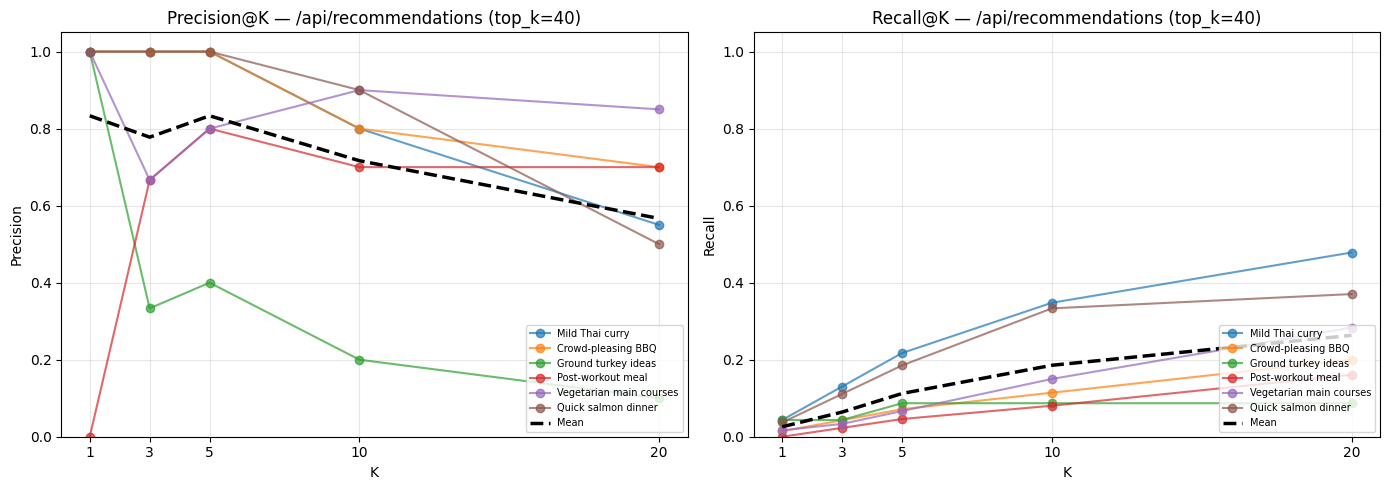

Saved → outputs/20260424_212113_reco_results.csv


In [26]:
print("Running /api/recommendations experiment (top_k=40)...")
df_reco = run_experiment(RECO_CASES, search_top_k=40, label="/api/recommendations")

display_cols = ["description", "n_relevant_pool"] + \
               [f"precision@{k}" for k in K_VALUES] + \
               [f"recall@{k}"    for k in K_VALUES]
print("\nResults:")
display(df_reco[display_cols].set_index("description"))

print(f"\nMean Precision@5  = {df_reco['precision@5'].mean():.3f}")
print(f"Mean Precision@10 = {df_reco['precision@10'].mean():.3f}")
print(f"Mean Recall@10    = {df_reco['recall@10'].mean():.3f}")
print(f"Mean Recall@20    = {df_reco['recall@20'].mean():.3f}")

plot_pr(df_reco, "/api/recommendations (top_k=40)")

os.makedirs("outputs", exist_ok=True)
path = f"outputs/{RUN_ID}_reco_results.csv"
df_reco.to_csv(path, index=False)
print(f"Saved → {path}")

---
## Summary
Aggregate Precision@K and Recall@K across all five endpoints.

=== Mean Precision@K and Recall@K by Endpoint ===


,precision@1,precision@3,precision@5,precision@10,precision@20,recall@1,recall@3,recall@5,recall@10,recall@20
endpoint,,,,,,,,,,
/api/chat,0.833,0.722,0.700,0.733,0.642,0.024,0.059,0.098,0.204,0.345
/api/planner/autofill,1.000,0.778,0.800,0.817,0.842,0.016,0.038,0.065,0.132,0.269
/api/planner/prompt,0.833,0.722,0.633,0.650,0.683,0.025,0.043,0.057,0.113,0.244
/api/recipes/search,0.667,0.667,0.667,0.567,0.517,0.016,0.060,0.092,0.156,0.253
/api/recommendations,0.833,0.778,0.833,0.717,0.567,0.026,0.064,0.112,0.185,0.263


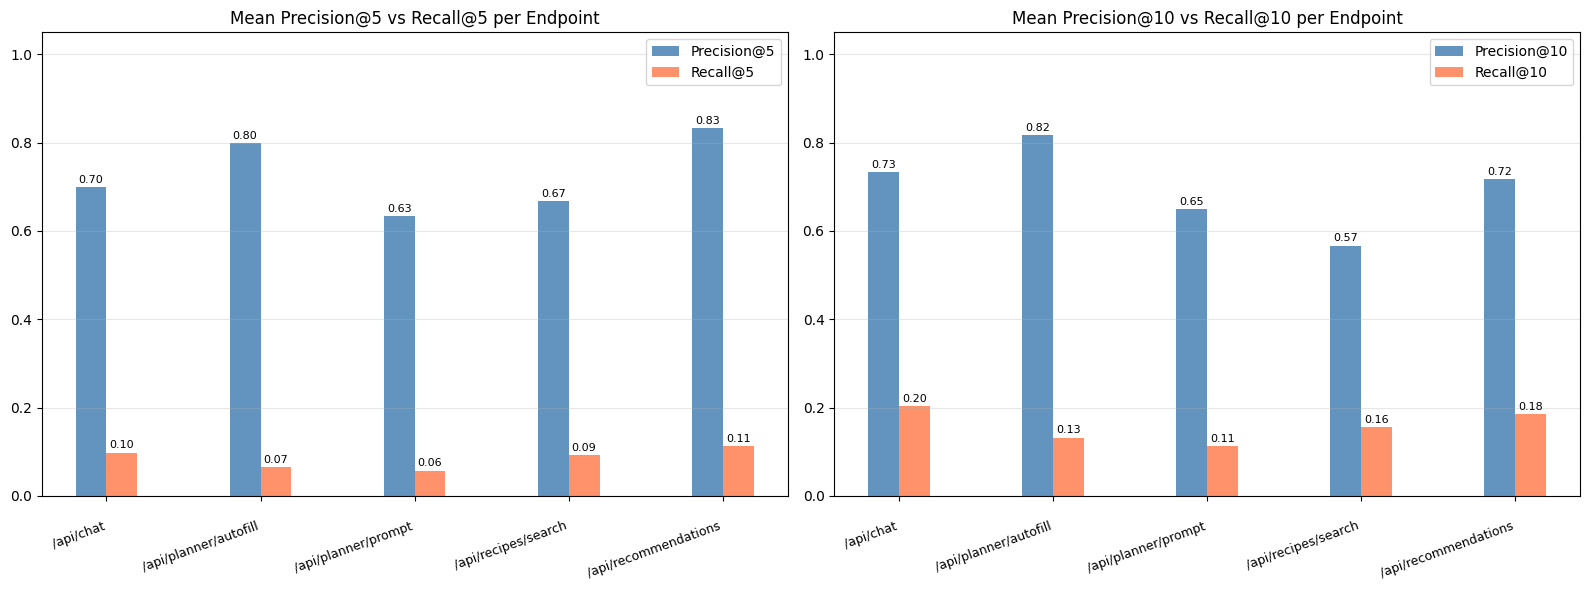

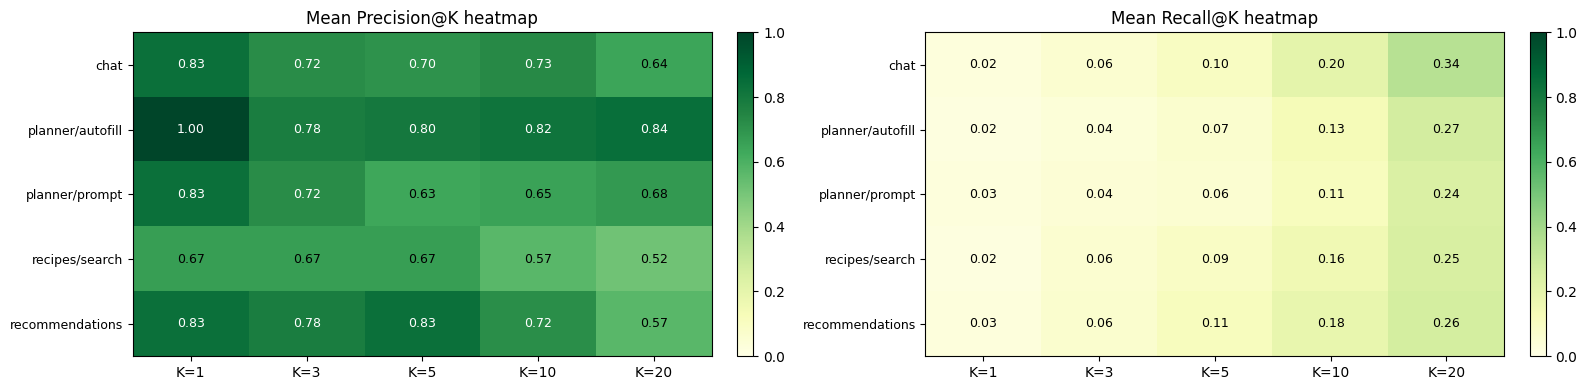

Saved → outputs/20260424_212113_all_results.csv
Saved → outputs/20260424_212113_summary.csv


In [27]:
all_results = pd.concat(
    [df_search, df_chat, df_planner, df_autofill, df_reco],
    ignore_index=True,
)

p_cols = [f"precision@{k}" for k in K_VALUES]
r_cols = [f"recall@{k}"    for k in K_VALUES]

summary = all_results.groupby("endpoint")[p_cols + r_cols].mean().round(3)
print("=== Mean Precision@K and Recall@K by Endpoint ===")
display(summary)

# ── Bar chart: P@5, P@10, R@5, R@10 side by side ─────────────────────────────
endpoints = summary.index.tolist()
x         = np.arange(len(endpoints))
width     = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, k in zip(axes, [5, 10]):
    p_vals = summary[f"precision@{k}"].values
    r_vals = summary[f"recall@{k}"].values

    bars_p = ax.bar(x - width / 2, p_vals, width, label=f"Precision@{k}", color="steelblue", alpha=0.85)
    bars_r = ax.bar(x + width / 2, r_vals, width, label=f"Recall@{k}",    color="coral",     alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [e.replace("/api/", "\n/api/").replace("/api\n/api/", "/api/") for e in endpoints],
        rotation=20, ha="right", fontsize=9,
    )
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Mean Precision@{k} vs Recall@{k} per Endpoint")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)

    for bar in list(bars_p) + list(bars_r):
        h = bar.get_height()
        ax.annotate(
            f"{h:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 3), textcoords="offset points",
            ha="center", fontsize=8,
        )

plt.tight_layout()
plt.show()

# ── Heatmap: mean Precision@K and Recall@K across endpoints ──────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 4))

for ax, cols, metric in zip(axes2, [p_cols, r_cols], ["Precision", "Recall"]):
    data = summary[cols].values
    im = ax.imshow(data, aspect="auto", cmap="YlGn", vmin=0, vmax=1)
    ax.set_xticks(range(len(K_VALUES)))
    ax.set_xticklabels([f"K={k}" for k in K_VALUES])
    ax.set_yticks(range(len(endpoints)))
    ax.set_yticklabels([e.replace("/api/", "") for e in endpoints], fontsize=9)
    ax.set_title(f"Mean {metric}@K heatmap")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(len(endpoints)):
        for j in range(len(K_VALUES)):
            ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=9,
                    color="black" if data[i, j] < 0.7 else "white")

plt.tight_layout()
plt.show()

# ── Save results to CSV ───────────────────────────────────────────────────────
os.makedirs("outputs", exist_ok=True)
all_path     = f"outputs/{RUN_ID}_all_results.csv"
summary_path = f"outputs/{RUN_ID}_summary.csv"
all_results.to_csv(all_path, index=False)
summary.to_csv(summary_path)
print(f"Saved → {all_path}")
print(f"Saved → {summary_path}")

In [28]:
# ── Full results table ────────────────────────────────────────────────────────
print("=== Full per-query results ===")
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.float_format", "{:.3f}".format)

full_table = all_results[
    ["endpoint", "description", "query", "n_relevant_pool"]
    + [f"precision@{k}" for k in K_VALUES]
    + [f"recall@{k}"    for k in K_VALUES]
].copy()
full_table["query"] = full_table["query"].str[:45]
display(full_table.set_index(["endpoint", "description"]))

=== Full per-query results ===


query  \
endpoint              description                                                                      
/api/recipes/search   Fast chicken ideas                                         quick chicken thing   
                      Authentic shakshuka guidance                          show me a good shakshuka   
                      Family veggie meals                              vegetarian dinner for my kids   
                      Mild ground beef dishes                   nothing too spicy, using ground beef   
                      Sweet potato and chickpea        what can I make with sweet potatoes and chick   
                      Thai food, no cilantro           need something Thai, my partner hates cilantr   
/api/chat             Ground beef sweet potato dish    What can I make with sweet potatoes and groun   
                      Quick tomato-based dinner        I need a quick dinner idea, under 20 minutes,   
                      Nut-free vegetarian chili        Show me some vegetarian chili options for a p   
                      Low sodium chicken rice          Sunday meal prep for the week: chicken and ri   
                      Salmon recipe without mushrooms  My partner hates mushrooms. Salmon dishes tha   
                      BBQ for a group                  BBQ ideas for a crowd. No ribs or pulled pork   
/api/planner/prompt   Budget vegetarian options                     vegetarian meals under $10 total   
                      Sunday meal prep ideas           I need something I can prep on Sunday for the   
                      Post-workout chicken                     quick chicken thing for after the gym   
                      Ground turkey and zucchini       what can I make with ground turkey and zucchi   
                      Asian, no cilantro               my partner hates cilantro - Asian-inspired fo   
                      Low sodium meal plan                        show me a week of low-sodium meals   
/api/planner/autofill Fast chicken dinners                                       quick chicken thing   
                      Low-calorie vegetarian             show me vegetarian meals under 500 calories   
                      Zucchini tomato ideas              what can I make with zucchini and tomatoes?   
                      High protein meal prep           need something for Sunday meal prep, high pro   
                      Simple date night                date night dinner ideas, nothing too complica   
                      Thai, no cilantro                 my partner hates cilantro, show me some Thai   
/api/recommendations  Mild Thai curry                          show me Thai curries, but not too hot   
                      Crowd-pleasing BBQ                                       BBQ stuff for a crowd   
                      Ground turkey ideas                        What can I make with ground turkey?   
                      Post-workout meal                Need something quick and filling after the gy   
                      Vegetarian main courses          vegetarian mains my partner will actually eat   
                      Quick salmon dinner                             under 40 minute salmon dinners   

                                                       n_relevant_pool  \
endpoint              description                                        
/api/recipes/search   Fast chicken ideas                            98   
                      Authentic shakshuka guidance                  27   
                      Family veggie meals                           72   
                      Mild ground beef dishes                       23   
                      Sweet potato and chickpea                     12   
                      Thai food, no cilantro                        28   
/api/chat             Ground beef sweet potato dish                 27   
                      Quick tomato-based dinner                     56   
                      Nut-